In [3]:
import pandas as pd

df = pd.read_csv('../data/preprocessed/final_master_training_set.csv')

In [4]:


df = df[['text_features', 'classification']]
print(df.head())

                                       text_features   classification
0  Adaptation Platform Canada (2012) Strategic pl...  adaptation only
1  Canadian Agricultural Adaptation Program Canad...  adaptation only
2  Climate Change Adaptation Act Japan (2015) Pol...  adaptation only
3  Climate Ready States and Cities Initiative Uni...  adaptation only
4  Climate Ready Water Utilities (CRWU) United St...  adaptation only


In [5]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(5455, 2)
(1364, 2)


In [6]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])
#nb diff between transform and fit transform

In [7]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['classification'])
test['pred'] = clf.predict(test_vectors)

In [8]:
test.head()

,text_features,classification,pred
1,Canadian Agricultural Adaptation Program Canad...,adaptation only,mitigation only
24,US Climate Action Plan United States of Americ...,adaptation only,adaptation only
26,Environmental and Climate Change Policy Cambod...,adaptation only,both
34,Flood Risk Management Act (No. 620/2010) Finla...,adaptation only,adaptation only
46,National Adaptation Strategy to Address Climat...,adaptation only,mitigation only


In [9]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['classification'], test['pred']))
print(metrics.precision_score(test['classification'], test['pred'], average='macro'))
print(metrics.recall_score(test['classification'], test['pred'], average='macro'))

0.9215542521994134
0.7998255784002085
0.7196944317547332


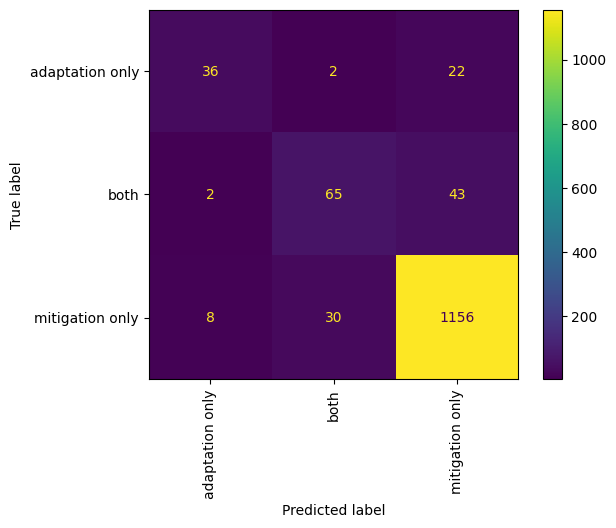

In [10]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()

In [11]:
# --- KNN TEST PREDICTOR ---
def test_knn_model(sample_text):
    # Transform text using the CountVectorizer from this notebook
    sample_vec = vectorizer.transform([sample_text])
    
    # Predict
    prediction = clf.predict(sample_vec)[0]
    
    # Get probabilities (if your KNN is configured for it)
    try:
        probs = clf.predict_proba(sample_vec)[0]
        conf = f"{max(probs)*100:.1f}%"
    except:
        conf = "N/A"
    
    print(f"--- KNN Prediction Results ---")
    print(f"Text: {sample_text[:100]}...")
    print(f"Label: {prediction}")
    print(f"Confidence: {conf}")

# Test it
test_string = "Implementing coastal barriers and sea walls to protect from rising sea levels."
test_knn_model(test_string)

--- KNN Prediction Results ---
Text: Implementing coastal barriers and sea walls to protect from rising sea levels....
Label: mitigation only
Confidence: 80.0%
